In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent.parent))
from regime_utils import read_csv, write_csv

In [2]:
#All daily series are resampled to weekly frequency using week-ending Friday values, taking the last available observation within each week.

t10 = read_csv("t10y2y.csv", parse_dates=["Date"])
t10 = t10.set_index("Date").sort_index()

In [3]:
t10_weekly = (
    t10
    .resample("W-FRI")
    .last()
)

In [4]:
print(t10_weekly.head())

            T10Y2Y
Date              
1994-01-07    1.61
1994-01-14    1.61
1994-01-21    1.64
1994-01-28    1.60
1994-02-04    1.52


In [5]:
write_csv(t10_weekly, "t10_weekly.csv")

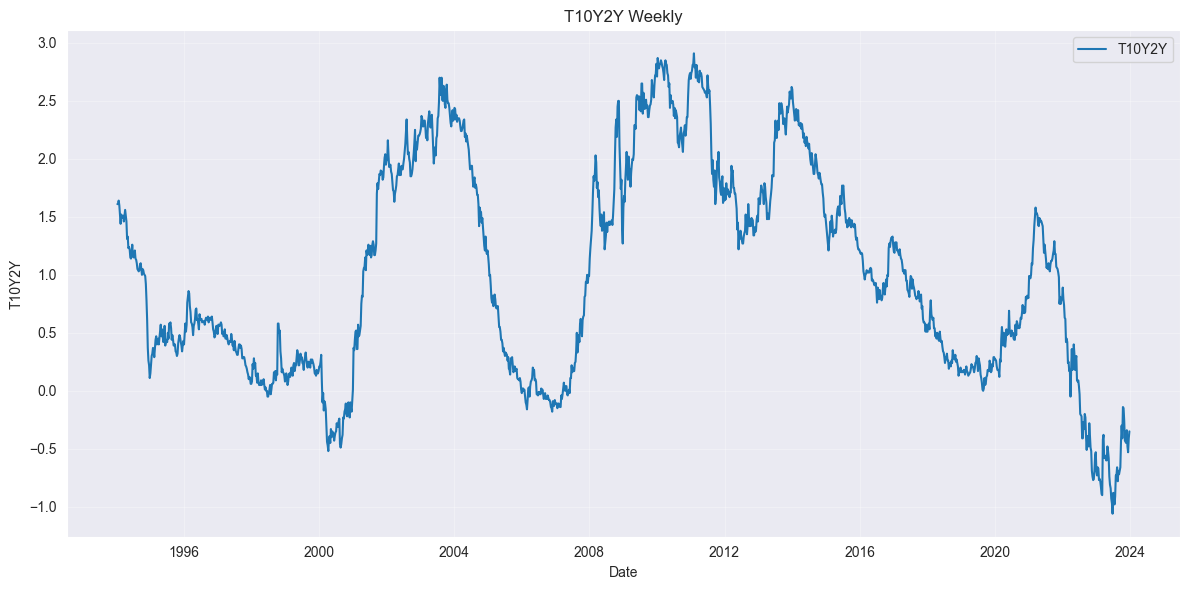

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(t10_weekly.index, t10_weekly["T10Y2Y"], label="T10Y2Y", color="tab:blue")
plt.xlabel("Date")
plt.ylabel("T10Y2Y")
plt.title("T10Y2Y Weekly")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()